In [1]:
# %% [markdown]
# # 🫀 Heart Disease Prediction using Classical ML Models
# **Dataset**: UCI Heart Disease (Cleveland) — 303 patients, 14 features
# **Goal**: Predict whether a patient has heart disease (binary classification)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set plot style for clean, readable charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [9]:
df = pd.read_csv("data/heart.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(10)


DATASET OVERVIEW

Shape: 303 rows × 14 columns



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [10]:
print("DATA TYPES & NON-NULL COUNTS")
print("-" * 40)
df.info()

DATA TYPES & NON-NULL COUNTS
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
print("\nSTATISTICAL SUMMARY")
print("-" * 40)
df.describe().round(2)



STATISTICAL SUMMARY
----------------------------------------


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [12]:
print("\nMISSING VALUES")
print("-" * 40)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✅")


MISSING VALUES
----------------------------------------
No missing values ✅


In [13]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows...")
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")


Duplicate rows: 1
Removing 1 duplicate rows...
New shape: (302, 14)


In [14]:
feature_descriptions = {
    'age': 'Age in years',
    'sex': 'Sex (1 = male, 0 = female)',
    'cp': 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)',
    'restecg': 'Resting ECG results (0-2)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise-induced angina (1 = yes, 0 = no)',
    'oldpeak': 'ST depression induced by exercise',
    'slope': 'Slope of peak exercise ST segment (0-2)',
    'ca': 'Number of major vessels colored by fluoroscopy (0-3)',
    'thal': 'Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect, 3 = ?)',
    'target': '1 = has heart disease, 0 = no heart disease'
}

print("\nFEATURE DESCRIPTIONS")
print("-" * 60)
for col, desc in feature_descriptions.items():
    print(f"  {col:12s} → {desc}")



FEATURE DESCRIPTIONS
------------------------------------------------------------
  age          → Age in years
  sex          → Sex (1 = male, 0 = female)
  cp           → Chest pain type (0-3)
  trestbps     → Resting blood pressure (mm Hg)
  chol         → Serum cholesterol (mg/dl)
  fbs          → Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
  restecg      → Resting ECG results (0-2)
  thalach      → Maximum heart rate achieved
  exang        → Exercise-induced angina (1 = yes, 0 = no)
  oldpeak      → ST depression induced by exercise
  slope        → Slope of peak exercise ST segment (0-2)
  ca           → Number of major vessels colored by fluoroscopy (0-3)
  thal         → Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect, 3 = ?)
  target       → 1 = has heart disease, 0 = no heart disease


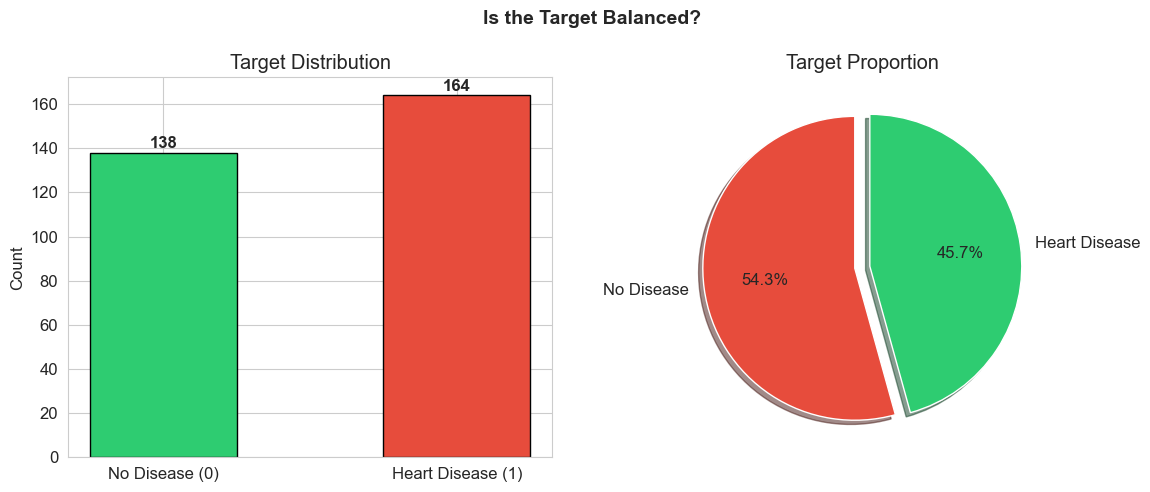


Class ratio: 0.84
→ Fairly balanced, no need for SMOTE or class weights


In [15]:
# --- 3.1 Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
for i, v in enumerate(target_counts.values):
    axes[0].text(target_counts.index[i], v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Target Proportion')

plt.suptitle('Is the Target Balanced?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = target_counts.min() / target_counts.max()
print(f"\nClass ratio: {ratio:.2f}")
print("→ Fairly balanced, no need for SMOTE or class weights" if ratio > 0.7
      else "→ Slightly imbalanced, may consider class weights")


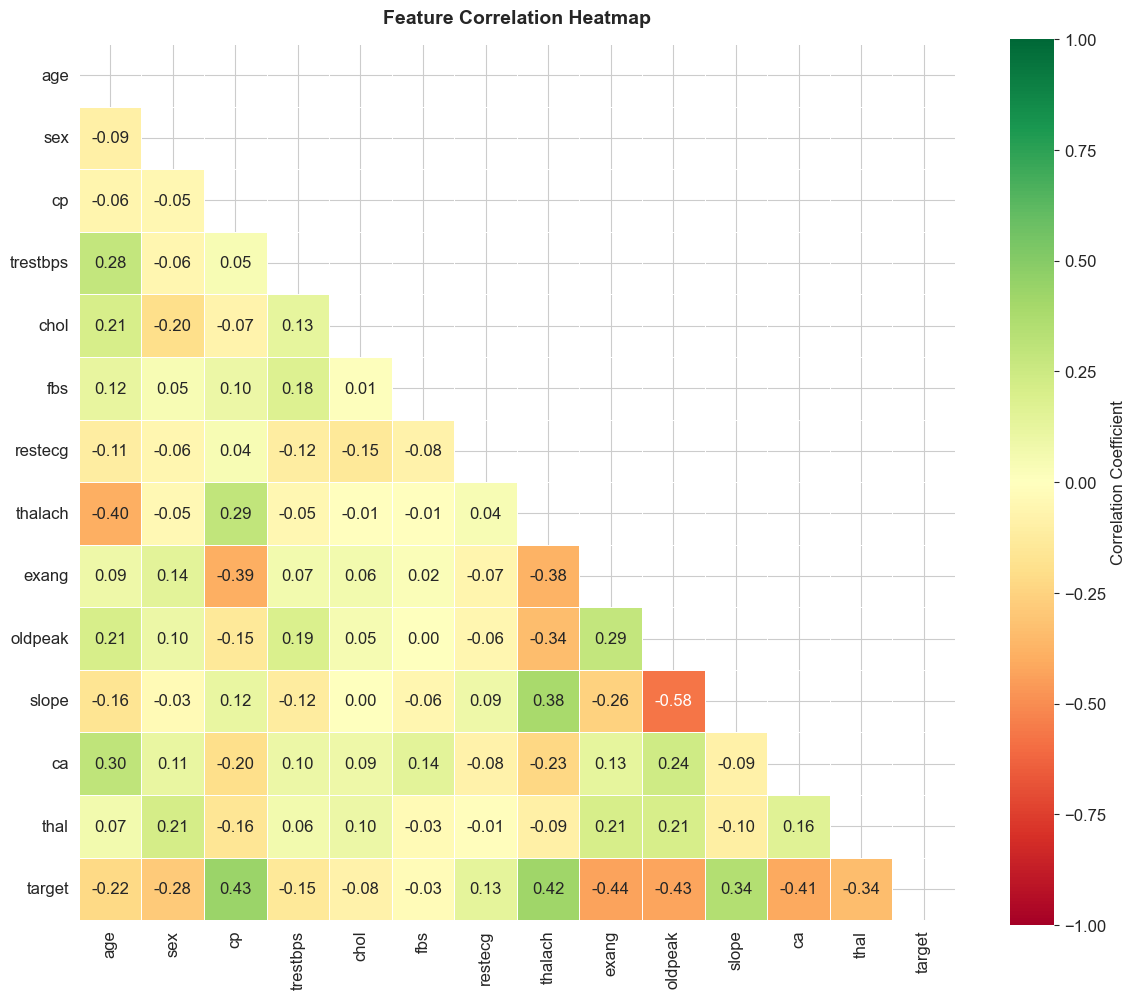


Top features correlated with target:
----------------------------------------
  exang        │ 0.436 █████████████
  cp           │ 0.432 ████████████
  oldpeak      │ 0.429 ████████████
  thalach      │ 0.420 ████████████
  ca           │ 0.409 ████████████
  slope        │ 0.344 ██████████
  thal         │ 0.343 ██████████
  sex          │ 0.284 ████████
  age          │ 0.221 ██████
  trestbps     │ 0.146 ████
  restecg      │ 0.135 ████
  chol         │ 0.081 ██
  fbs          │ 0.027 


In [16]:
# --- 3.2 Correlation Heatmap ---
# WHY: Identifies which features are most correlated with the target,
# and spots multicollinearity between features (redundant info)

fig, ax = plt.subplots(figsize=(12, 10))
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Highlight top correlations with target
target_corr = correlation['target'].drop('target').abs().sort_values(ascending=False)
print("\nTop features correlated with target:")
print("-" * 40)
for feat, corr_val in target_corr.items():
    bar = '█' * int(corr_val * 30)
    print(f"  {feat:12s} │ {corr_val:.3f} {bar}")


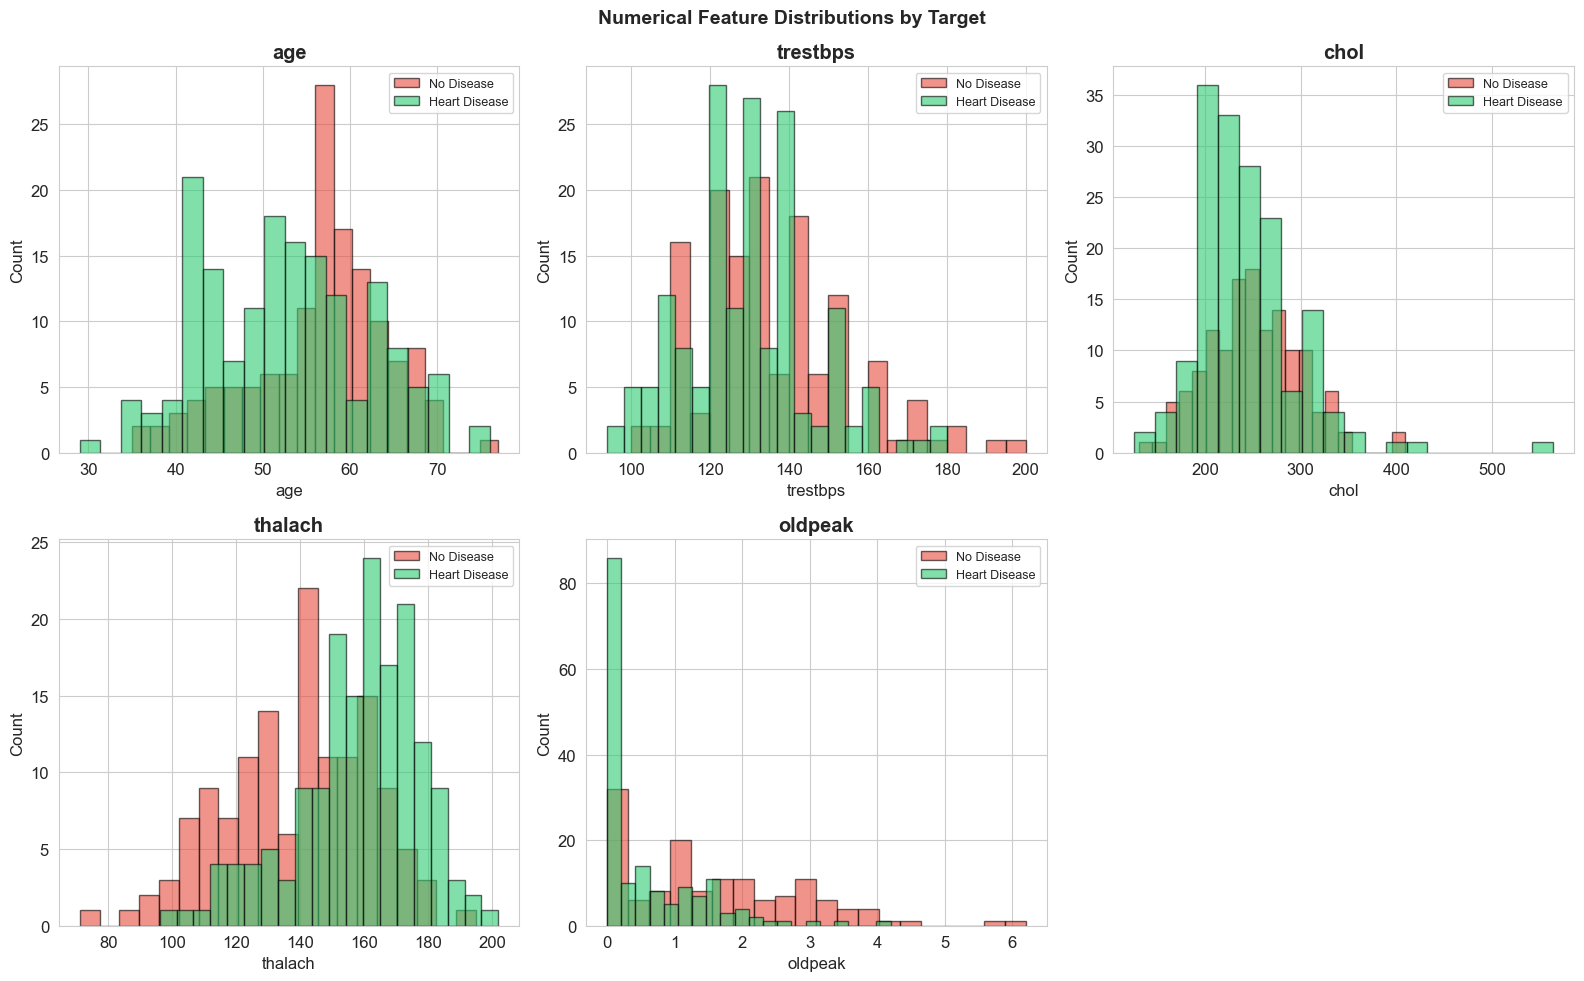

In [17]:
# --- 3.3 Feature Distributions by Target Class ---
# WHY: Shows how each feature differs between healthy and sick patients
# Features with clear separation → more predictive power

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    ax = axes[idx]
    for target_val, color, label in [(0, '#e74c3c', 'No Disease'), (1, '#2ecc71', 'Heart Disease')]:
        subset = df[df['target'] == target_val][col]
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# Remove the extra subplot
axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

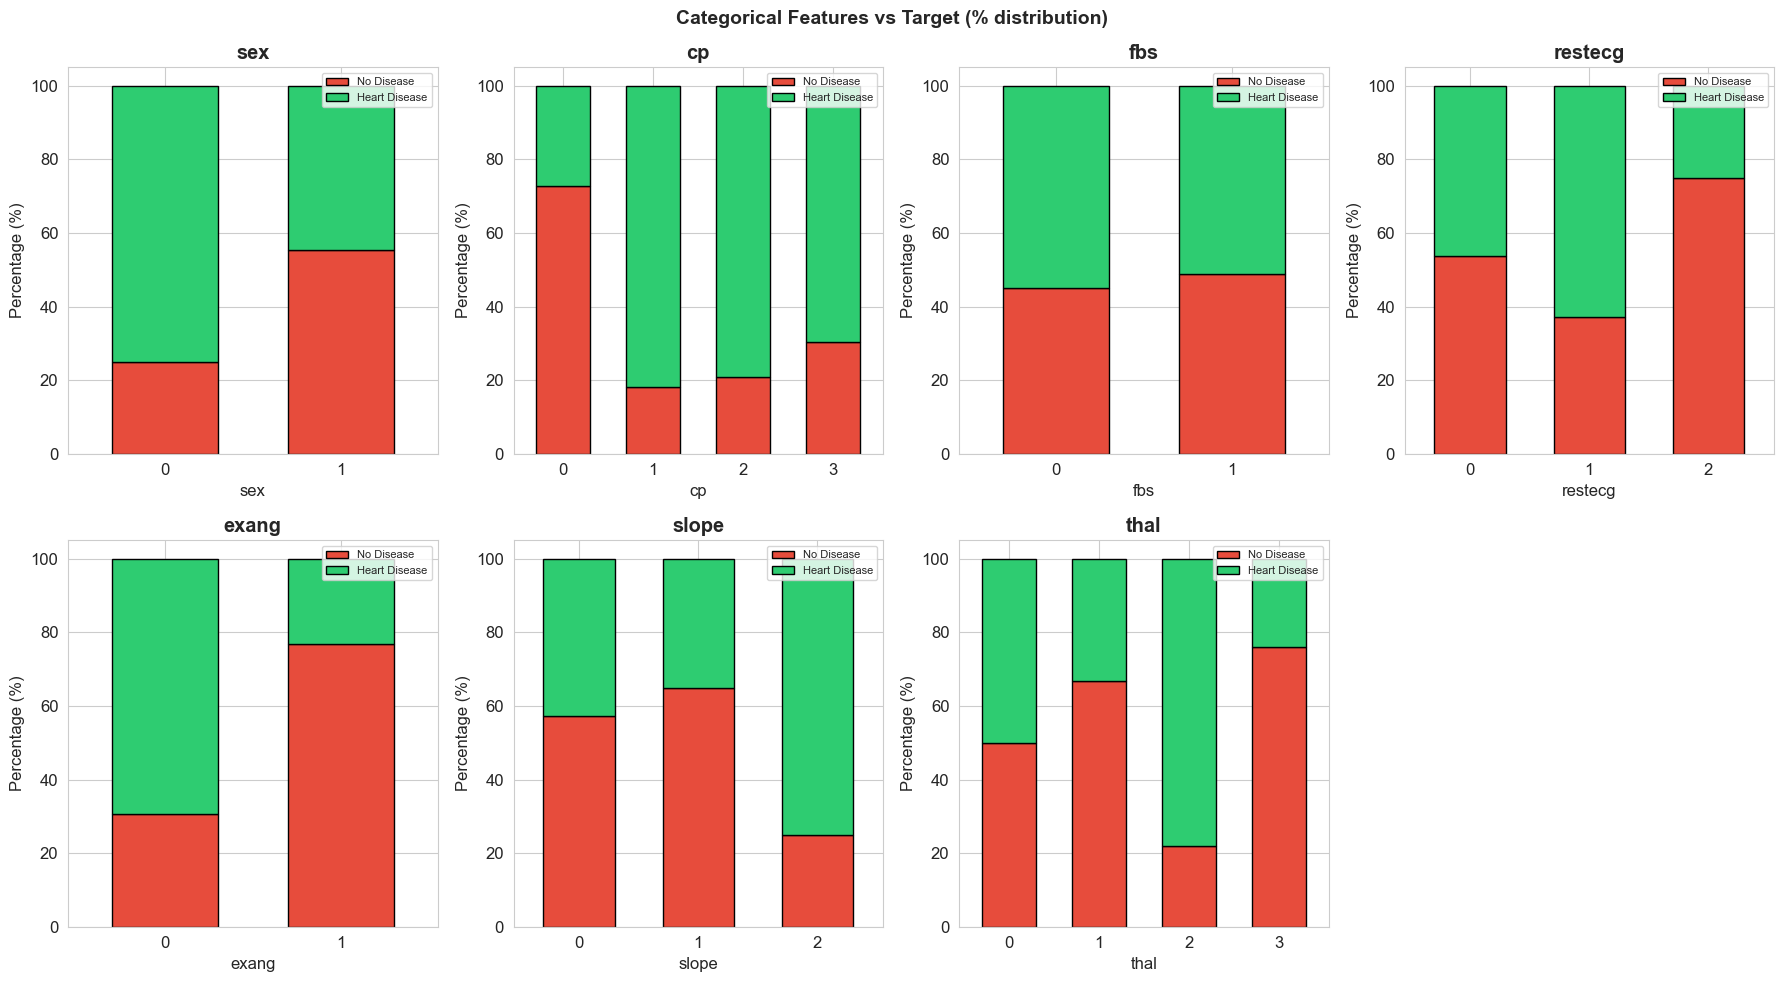

In [18]:
# --- 3.4 Categorical Feature Analysis ---
# WHY: Shows if certain categories strongly indicate heart disease

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    ax = axes[idx]
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'],
            edgecolor='black', width=0.6)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel(col)
    ax.legend(['No Disease', 'Heart Disease'], fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Remove the extra subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Features vs Target (% distribution)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

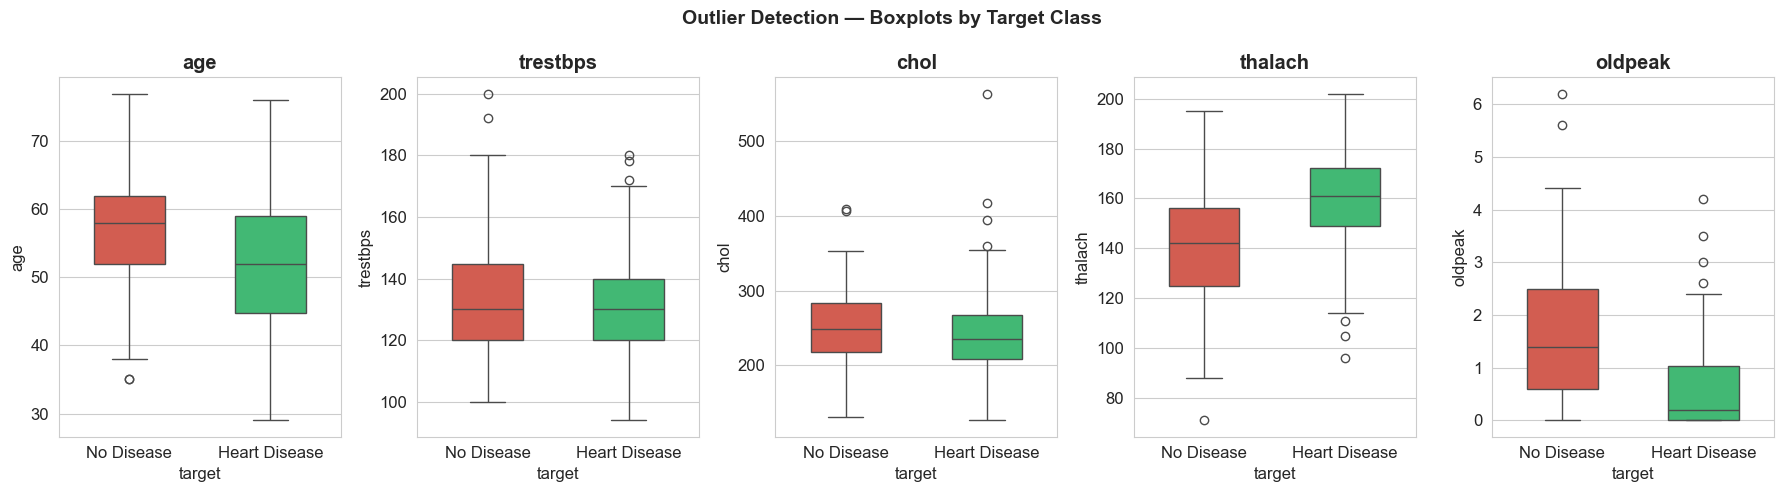


💡 Insight: Cholesterol and resting BP have outliers → confirms StandardScaler is better than MinMaxScaler


In [19]:
# --- 3.5 Boxplots for Outlier Detection ---
# WHY: Outliers affect StandardScaler less than MinMaxScaler,
# confirming our choice of StandardScaler

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for idx, col in enumerate(numerical_features):
    sns.boxplot(data=df, x='target', y=col, ax=axes[idx],
                palette=['#e74c3c', '#2ecc71'], width=0.5)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xticklabels(['No Disease', 'Heart Disease'])

plt.suptitle('Outlier Detection — Boxplots by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Insight: Cholesterol and resting BP have outliers → confirms StandardScaler is better than MinMaxScaler")


### 4. Preprocessing

#### Key Decisions (and why):

 **1. Train/Test Split BEFORE preprocessing** → Prevents data leakage.
    The scaler/encoder must learn ONLY from training data, not test data.
    Otherwise, test performance is inflated (the model has "seen" test statistics).

 **2. One-Hot Encoding for cp, restecg, thal** → These are NOMINAL categories
    (no natural order). Label Encoding would imply cp=3 > cp=1, which is wrong
    and would mislead distance-based models (KNN, SVM).

 **3. StandardScaler for numerical features** → KNN and SVM use distance metrics.
    Without scaling, features like cholesterol (~120-560) dominate over oldpeak (~0-6).
    StandardScaler chosen over MinMaxScaler because it handles outliers better
    (we saw cholesterol/BP have outliers in the boxplots above).

 **4. ColumnTransformer** → Applies different transformations to different column
    groups in one clean step. Alternative: manually transform columns and concatenate,
    which is error-prone and messy.

In [20]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (302, 13)
Target distribution:
target
1    164
0    138
Name: count, dtype: int64


In [21]:
# Train/Test Split — BEFORE any preprocessing
# WHY: 80/20 is standard. Stratify ensures same disease ratio in train and test.
# Without stratify, random split could put most disease cases in one set.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 241 samples
Test set:     61 samples

Train target distribution:
target
1    0.544
0    0.456
Name: proportion, dtype: float64

Test target distribution:
target
1    0.541
0    0.459
Name: proportion, dtype: float64


In [22]:
# Define column groups by type
# WHY each group gets different treatment:

# Numerical → StandardScaler (distance-based models need scaled features)
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Binary → Leave as-is (already 0/1, encoding adds nothing)
binary_cols = ['sex', 'fbs', 'exang']

# Nominal categorical → One-Hot Encode (no natural order exists)
# WHY NOT Label Encode? cp=3 is NOT "greater than" cp=1, they're just types.
# KNN/SVM would compute distance between these fake numbers → wrong results.
nominal_cols = ['cp', 'restecg', 'thal']

# Ordinal → Keep as numbers (slope has meaningful order: upsloping→flat→downsloping)
ordinal_cols = ['slope', 'ca']

print("Column groups defined:")
print(f"  Numerical (→ StandardScaler):    {numerical_cols}")
print(f"  Binary (→ passthrough):          {binary_cols}")
print(f"  Nominal (→ One-Hot Encode):      {nominal_cols}")
print(f"  Ordinal (→ passthrough):         {ordinal_cols}")

Column groups defined:
  Numerical (→ StandardScaler):    ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Binary (→ passthrough):          ['sex', 'fbs', 'exang']
  Nominal (→ One-Hot Encode):      ['cp', 'restecg', 'thal']
  Ordinal (→ passthrough):         ['slope', 'ca']


In [23]:
# Build ColumnTransformer
# WHY ColumnTransformer? Applies different preprocessing to different columns
# in one step. Alternative: manually scale, encode, and concatenate arrays
# → error-prone, messy, and doesn't integrate into sklearn Pipelines.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),        # Scale numericals
        ('nom', OneHotEncoder(drop='first',               # One-hot encode nominals
                              sparse_output=False,
                              handle_unknown='ignore'),
         nominal_cols),
        ('bin', 'passthrough', binary_cols),               # Keep binary as-is
        ('ord', 'passthrough', ordinal_cols),              # Keep ordinal as-is
    ]
)

# WHY drop='first' in OneHotEncoder?
# Avoids multicollinearity (the "dummy variable trap").
# If cp has 4 categories, 3 dummy columns are enough — the 4th is implied.
# Example: if cp_1=0, cp_2=0, cp_3=0 → it must be cp_0.

print("✅ Preprocessor built!")
print("\nNote: drop='first' in OneHotEncoder avoids multicollinearity")
print("      (3 dummies for 4 categories — the 4th is implied)")

✅ Preprocessor built!

Note: drop='first' in OneHotEncoder avoids multicollinearity
      (3 dummies for 4 categories — the 4th is implied)


### 5. Model Training

We train 7 models, each chosen for a specific reason:

 | Model | Why |
 |-------|-----|
 | Logistic Regression | Simple, interpretable baseline. If this works well, complexity isn't needed |
 | KNN | Tests "similar patients → similar outcomes". Non-parametric, no assumptions |
 | SVM (RBF) | Finds optimal decision boundary. Powerful for mid-sized data |
 | Decision Tree | Fully interpretable — doctors can follow the decision logic |
 | Random Forest | Ensemble of trees. Reduces overfitting of a single tree |
 | Gradient Boosting | Sequentially corrects errors. Usually top performer on tabular data |
 | XGBoost | Optimized GB — faster, regularized, handles missing values natively |

In [24]:
# Define all 7 models
# Each is wrapped in a Pipeline with the preprocessor
# WHY Pipeline? Ensures preprocessing + model are treated as one unit.
# During cross-validation, preprocessing is fit ONLY on training folds → no leakage.

models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
        # WHY max_iter=1000? Default 100 sometimes doesn't converge on this dataset
    ]),

    'K-Nearest Neighbors': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
        # WHY k=5? Odd number avoids ties. 5 is a good default for ~300 samples.
        # Too small → overfitting. Too large → underfitting.
    ]),

    'SVM (RBF Kernel)': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
        # WHY RBF kernel? Handles non-linear decision boundaries.
        # Linear kernel assumes data is linearly separable — often not true for medical data.
        # probability=True → needed for ROC-AUC calculation.
    ]),

    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
        # WHY max_depth=5? Unconstrained tree → overfits badly on 300 samples.
        # Depth 5 gives enough complexity without memorizing training data.
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
        # WHY 100 trees? Standard default. More trees = better but diminishing returns.
        # WHY max_depth=10? Deeper than single tree (ensemble averaging reduces overfitting).
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                   max_depth=3, random_state=42))
        # WHY learning_rate=0.1? Lower = more robust (each tree contributes less).
        # WHY max_depth=3? Boosting uses shallow "stumps" — deep trees overfit in boosting.
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=3, random_state=42,
                                      eval_metric='logloss', use_label_encoder=False))
        # WHY XGBoost over sklearn's GradientBoosting?
        # - Built-in L1/L2 regularization → reduces overfitting
        # - Handles missing values natively (not relevant here but good practice)
        # - Faster training via parallel computation
        # - eval_metric='logloss' → proper metric for binary classification
    ]),
}

print(f"✅ {len(models)} models defined!\n")
for name in models:
    print(f"  • {name}")

✅ 7 models defined!

  • Logistic Regression
  • K-Nearest Neighbors
  • SVM (RBF Kernel)
  • Decision Tree
  • Random Forest
  • Gradient Boosting
  • XGBoost


In [25]:
# Train all models and store predictions
print("=" * 60)
print("TRAINING ALL MODELS")
print("=" * 60)

results = {}

for name, pipeline in models.items():
    print(f"\n🔄 Training {name}...")

    # Fit on training data
    pipeline.fit(X_train, y_train)

    # Predict on test data
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # Probability of class 1

    # Calculate metrics
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

    print(f"   ✅ Accuracy: {results[name]['accuracy']:.4f} | "
          f"F1: {results[name]['f1']:.4f} | "
          f"ROC-AUC: {results[name]['roc_auc']:.4f}")

print("\n" + "=" * 60)
print("ALL MODELS TRAINED!")
print("=" * 60)

TRAINING ALL MODELS

🔄 Training Logistic Regression...
   ✅ Accuracy: 0.8033 | F1: 0.8286 | ROC-AUC: 0.8680

🔄 Training K-Nearest Neighbors...
   ✅ Accuracy: 0.7377 | F1: 0.7576 | ROC-AUC: 0.8804

🔄 Training SVM (RBF Kernel)...
   ✅ Accuracy: 0.8197 | F1: 0.8533 | ROC-AUC: 0.9156

🔄 Training Decision Tree...
   ✅ Accuracy: 0.7541 | F1: 0.7887 | ROC-AUC: 0.8095

🔄 Training Random Forest...
   ✅ Accuracy: 0.7541 | F1: 0.7887 | ROC-AUC: 0.9031

🔄 Training Gradient Boosting...
   ✅ Accuracy: 0.7705 | F1: 0.7941 | ROC-AUC: 0.8669

🔄 Training XGBoost...
   ✅ Accuracy: 0.7705 | F1: 0.8000 | ROC-AUC: 0.8690

ALL MODELS TRAINED!


### 6. Evaluation & Model Comparison

 **Why not just accuracy?**
 If 60% of patients are healthy, a model that always says "healthy" gets 60% accuracy.
 But it catches ZERO sick patients → useless and dangerous.

 **Key metrics for medical prediction:**
 - **Recall** (Sensitivity): Of those actually sick, how many did we catch?
   → CRITICAL. Missing a heart disease case is life-threatening.
 - **Precision**: Of those predicted sick, how many actually are?
   → Avoids unnecessary treatments/anxiety.
 - **F1-Score**: Harmonic mean of precision & recall → balanced metric.
 - **ROC-AUC**: Overall discrimination ability across all threshold

In [26]:
# --- 6.1 Metrics Comparison Table ---
metrics_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['y_pred', 'y_prob']}
    for name, metrics in results.items()
}).T.round(4)

metrics_df = metrics_df.sort_values('f1', ascending=False)

print("MODEL COMPARISON (sorted by F1-Score)")
print("=" * 75)
print(metrics_df.to_string())

best_model_name = metrics_df.index[0]
print(f"\n🏆 Best model by F1-Score: {best_model_name}")


MODEL COMPARISON (sorted by F1-Score)
                     accuracy  precision  recall      f1  roc_auc
SVM (RBF Kernel)       0.8197     0.7619  0.9697  0.8533   0.9156
Logistic Regression    0.8033     0.7838  0.8788  0.8286   0.8680
XGBoost                0.7705     0.7568  0.8485  0.8000   0.8690
Gradient Boosting      0.7705     0.7714  0.8182  0.7941   0.8669
Decision Tree          0.7541     0.7368  0.8485  0.7887   0.8095
Random Forest          0.7541     0.7368  0.8485  0.7887   0.9031
K-Nearest Neighbors    0.7377     0.7576  0.7576  0.7576   0.8804

🏆 Best model by F1-Score: SVM (RBF Kernel)


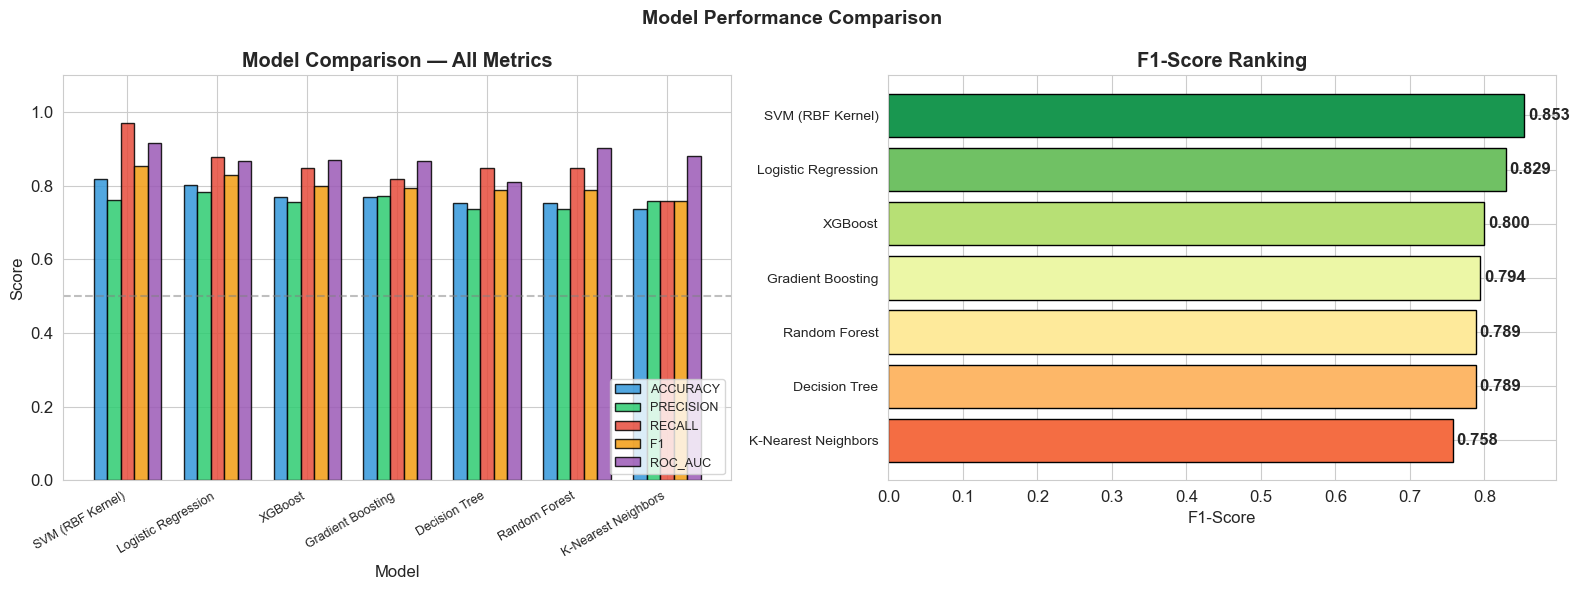

In [27]:
# --- 6.2 Visual Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics_df))
width = 0.15
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i * width, metrics_df[metric], width,
                label=metric.upper(), color=colors_bar[i], edgecolor='black', alpha=0.85)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison — All Metrics', fontweight='bold')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics_df.index, rotation=30, ha='right', fontsize=9)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')

# F1 Score horizontal bar
sorted_f1 = metrics_df['f1'].sort_values()
colors_f1 = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_f1)))
axes[1].barh(range(len(sorted_f1)), sorted_f1.values, color=colors_f1, edgecolor='black')
axes[1].set_yticks(range(len(sorted_f1)))
axes[1].set_yticklabels(sorted_f1.index, fontsize=10)
axes[1].set_xlabel('F1-Score')
axes[1].set_title('F1-Score Ranking', fontweight='bold')
for i, v in enumerate(sorted_f1.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


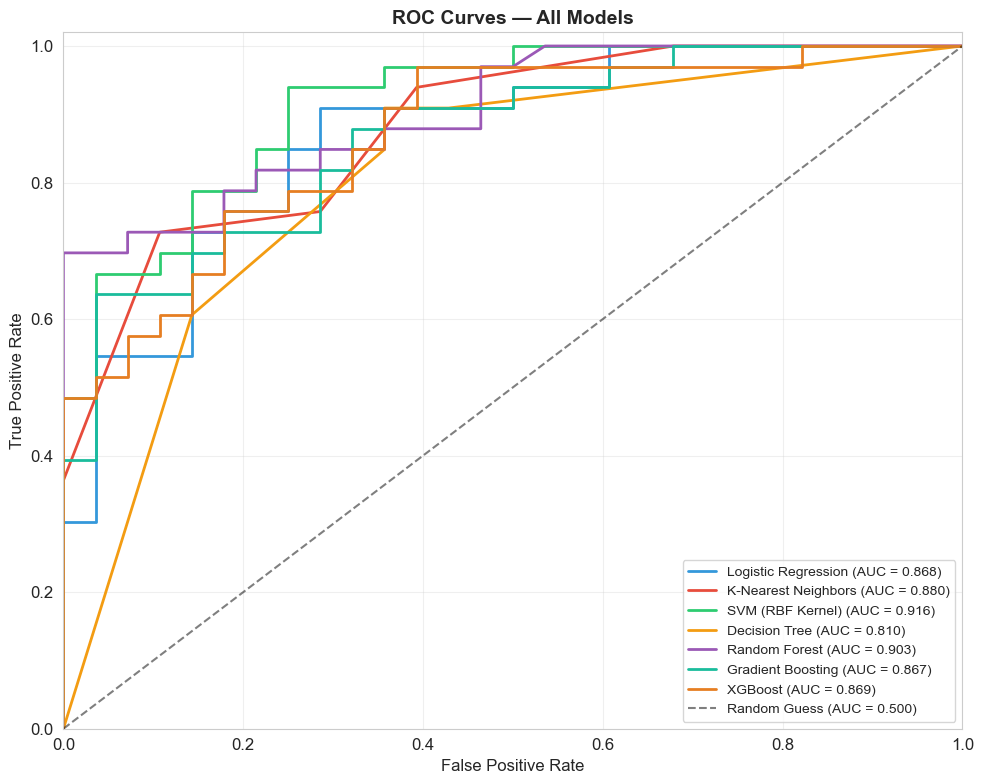

In [28]:
# --- 6.3 ROC Curves ---
# WHY ROC curves? Shows the tradeoff between True Positive Rate and False Positive Rate
# across ALL classification thresholds. A model hugging the top-left corner is best.

fig, ax = plt.subplots(figsize=(10, 8))

colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for (name, metrics), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    auc = metrics['roc_auc']
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

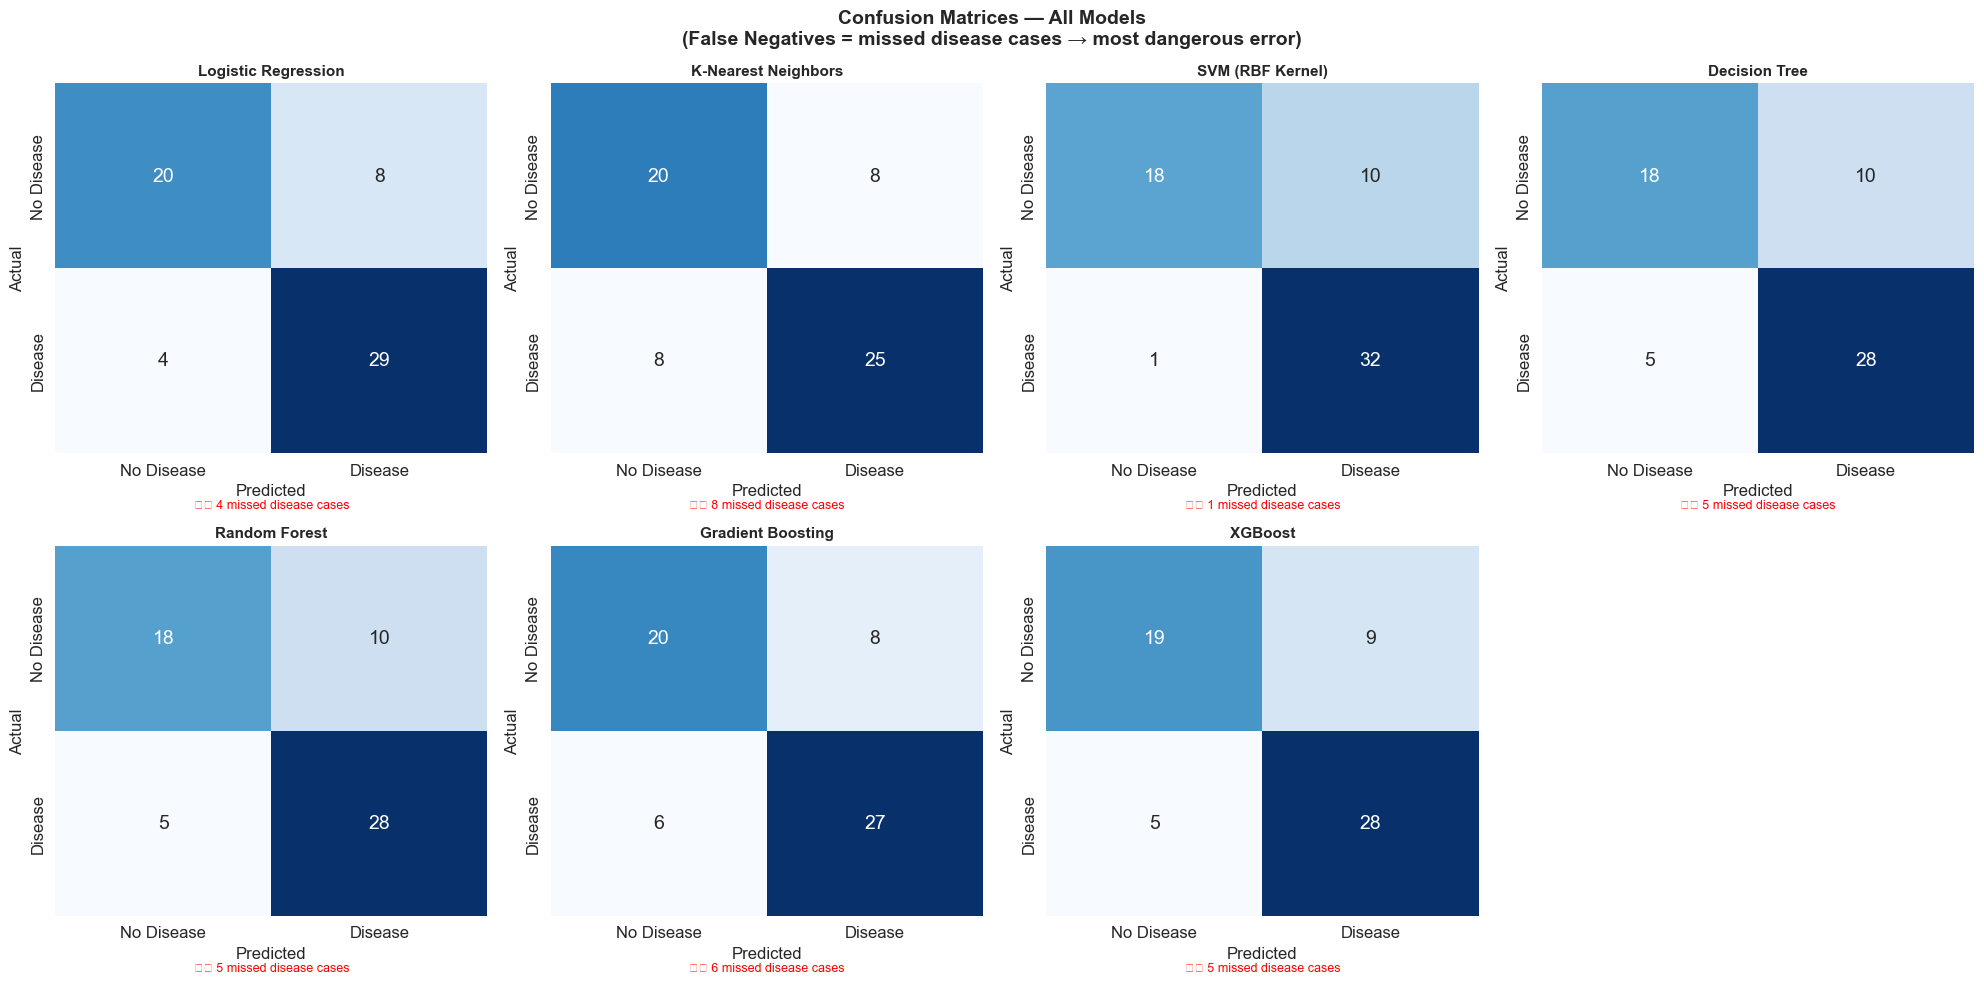

In [30]:
# --- 6.4 Confusion Matrices ---
# Shows exactly WHERE each model makes mistakes:
# - False Negatives (predicted healthy but actually sick) → DANGEROUS
# - False Positives (predicted sick but actually healthy) → unnecessary tests

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                cbar=False, annot_kws={'size': 14})
    axes[idx].set_title(name, fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    # Highlight false negatives (bottom-left) — the dangerous ones
    fn = cm[1][0]
    if fn > 0:
        axes[idx].text(0.5, -0.15, f'⚠️ {fn} missed disease cases',
                      transform=axes[idx].transAxes, ha='center',
                      fontsize=9, color='red')

# Remove extra subplot
axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — All Models\n(False Negatives = missed disease cases → most dangerous error)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [31]:
# --- 6.5 Detailed Classification Report for Best Model ---
print(f"\nDETAILED REPORT — {best_model_name}")
print("=" * 60)
print(classification_report(y_test, results[best_model_name]['y_pred'],
                            target_names=['No Disease', 'Heart Disease']))


DETAILED REPORT — SVM (RBF Kernel)
               precision    recall  f1-score   support

   No Disease       0.95      0.64      0.77        28
Heart Disease       0.76      0.97      0.85        33

     accuracy                           0.82        61
    macro avg       0.85      0.81      0.81        61
 weighted avg       0.85      0.82      0.81        61



### 7. Feature Importance

 **Why this matters:** In healthcare, interpretability is as important as accuracy.
 Doctors need to know WHICH health factors drive the prediction.
 Tree-based models provide built-in feature importance scores.

In [32]:
# Get feature names after preprocessing
# WHY this is tricky: OneHotEncoder creates new column names, so we need to
# reconstruct the full feature name list after ColumnTransformer.

# Fit preprocessor to get transformed feature names
preprocessor.fit(X_train)

# Get one-hot encoded feature names
ohe_features = preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_cols)
all_feature_names = list(numerical_cols) + list(ohe_features) + list(binary_cols) + list(ordinal_cols)

print(f"Total features after preprocessing: {len(all_feature_names)}")
print(f"Features: {all_feature_names}")

Total features after preprocessing: 18
Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'thal_1', 'thal_2', 'thal_3', 'sex', 'fbs', 'exang', 'slope', 'ca']


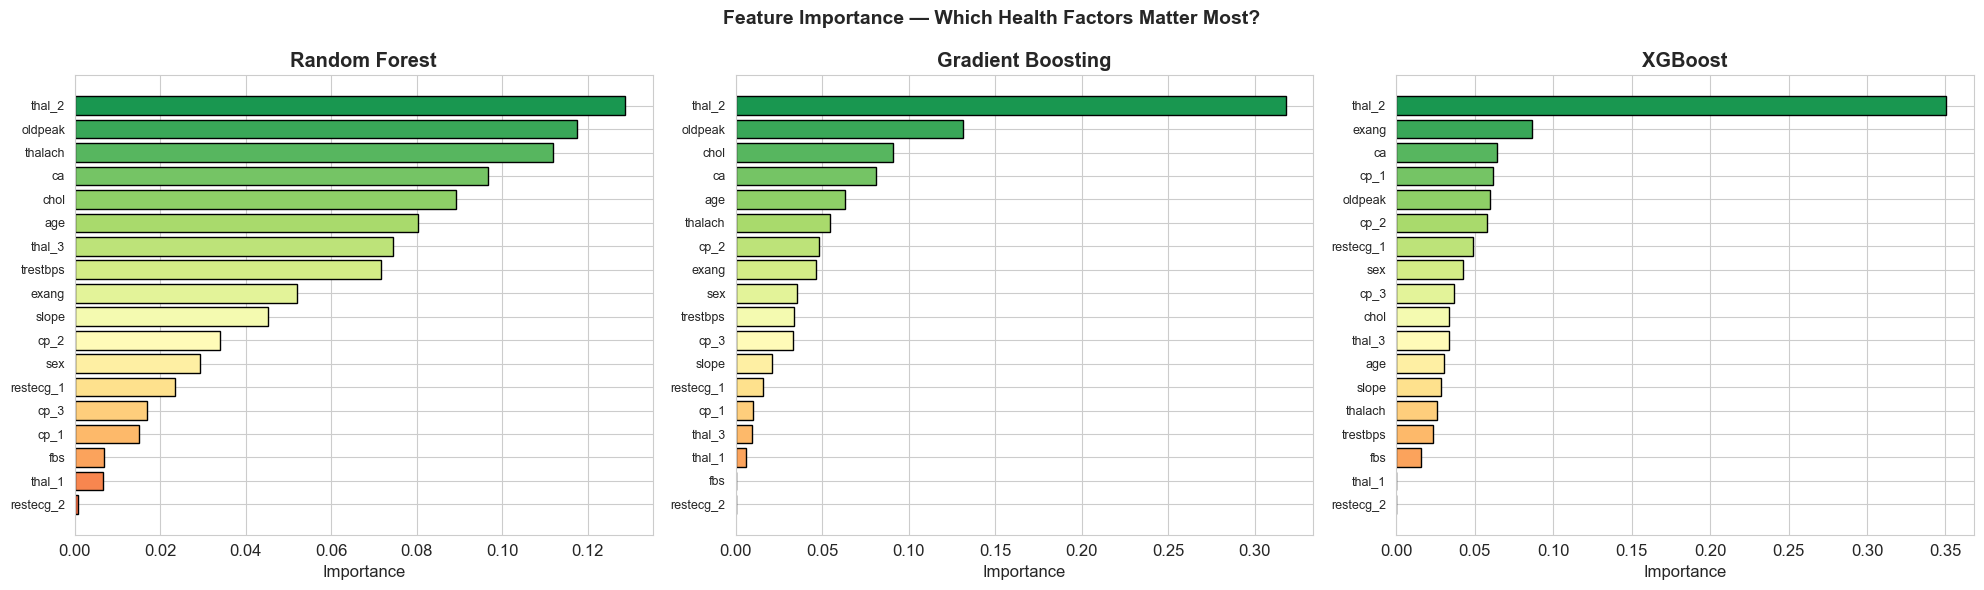


📊 TOP 5 MOST IMPORTANT FEATURES (averaged across tree models)
--------------------------------------------------
  1. thal_2          │ 0.2658 █████████████
  2. oldpeak         │ 0.1030 █████
  3. ca              │ 0.0808 ████
  4. chol            │ 0.0714 ███
  5. thalach         │ 0.0642 ███


In [33]:
# Extract feature importances from tree-based models
# WHY only tree-based? Linear models have coefficients, not importances.
# KNN/SVM don't provide feature importances natively.

tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, name in enumerate(tree_models):
    clf = models[name].named_steps['classifier']
    importances = clf.feature_importances_

    # Sort by importance
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True)

    # Plot
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
    axes[idx].barh(range(len(feat_imp)), feat_imp.values, color=colors_imp, edgecolor='black')
    axes[idx].set_yticks(range(len(feat_imp)))
    axes[idx].set_yticklabels(feat_imp.index, fontsize=9)
    axes[idx].set_xlabel('Importance')
    axes[idx].set_title(name, fontweight='bold')

plt.suptitle('Feature Importance — Which Health Factors Matter Most?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 5 most important features (averaged across tree models)
print("\n📊 TOP 5 MOST IMPORTANT FEATURES (averaged across tree models)")
print("-" * 50)
avg_importance = pd.DataFrame()
for name in tree_models:
    clf = models[name].named_steps['classifier']
    avg_importance[name] = clf.feature_importances_

avg_importance.index = all_feature_names
avg_importance['mean'] = avg_importance.mean(axis=1)
top_5 = avg_importance['mean'].sort_values(ascending=False).head(5)

for rank, (feat, imp) in enumerate(top_5.items(), 1):
    bar = '█' * int(imp * 50)
    print(f"  {rank}. {feat:15s} │ {imp:.4f} {bar}")

### 8. Cross-Validation

 **Why not just use the single train/test split results?**
 A single 80/20 split can be "lucky" or "unlucky" — the model might perform
 well just because the test set happened to be easy.

 **Stratified K-Fold Cross-Validation** solves this:
 - Splits data into K folds (K=5)
 - Trains K times, each time using a different fold as test
 - Reports mean ± std performance → much more reliable estimate

 **Why Stratified?** Ensures each fold maintains the same disease/healthy ratio.
 Regular K-Fold might create a fold with mostly healthy patients → misleading.

In [34]:
# Run 5-Fold Stratified CV on all models
print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"\n{name}:")
    print(f"  F1 scores per fold: {[f'{s:.4f}' for s in scores]}")
    print(f"  Mean F1: {scores.mean():.4f} ± {scores.std():.4f}")

5-FOLD STRATIFIED CROSS-VALIDATION

Logistic Regression:
  F1 scores per fold: ['0.9091', '0.8308', '0.7778', '0.8406', '0.8824']
  Mean F1: 0.8481 ± 0.0452

K-Nearest Neighbors:
  F1 scores per fold: ['0.8889', '0.8485', '0.7536', '0.7692', '0.7941']
  Mean F1: 0.8109 ± 0.0506

SVM (RBF Kernel):
  F1 scores per fold: ['0.9091', '0.7937', '0.7838', '0.8182', '0.8286']
  Mean F1: 0.8267 ± 0.0443

Decision Tree:
  F1 scores per fold: ['0.7500', '0.7385', '0.7838', '0.7541', '0.7606']
  Mean F1: 0.7574 ± 0.0150

Random Forest:
  F1 scores per fold: ['0.8852', '0.8254', '0.7838', '0.8529', '0.8451']
  Mean F1: 0.8385 ± 0.0335

Gradient Boosting:
  F1 scores per fold: ['0.8333', '0.7812', '0.7887', '0.8116', '0.8571']
  Mean F1: 0.8144 ± 0.0281

XGBoost:
  F1 scores per fold: ['0.8667', '0.7812', '0.7606', '0.8235', '0.8571']
  Mean F1: 0.8178 ± 0.0414


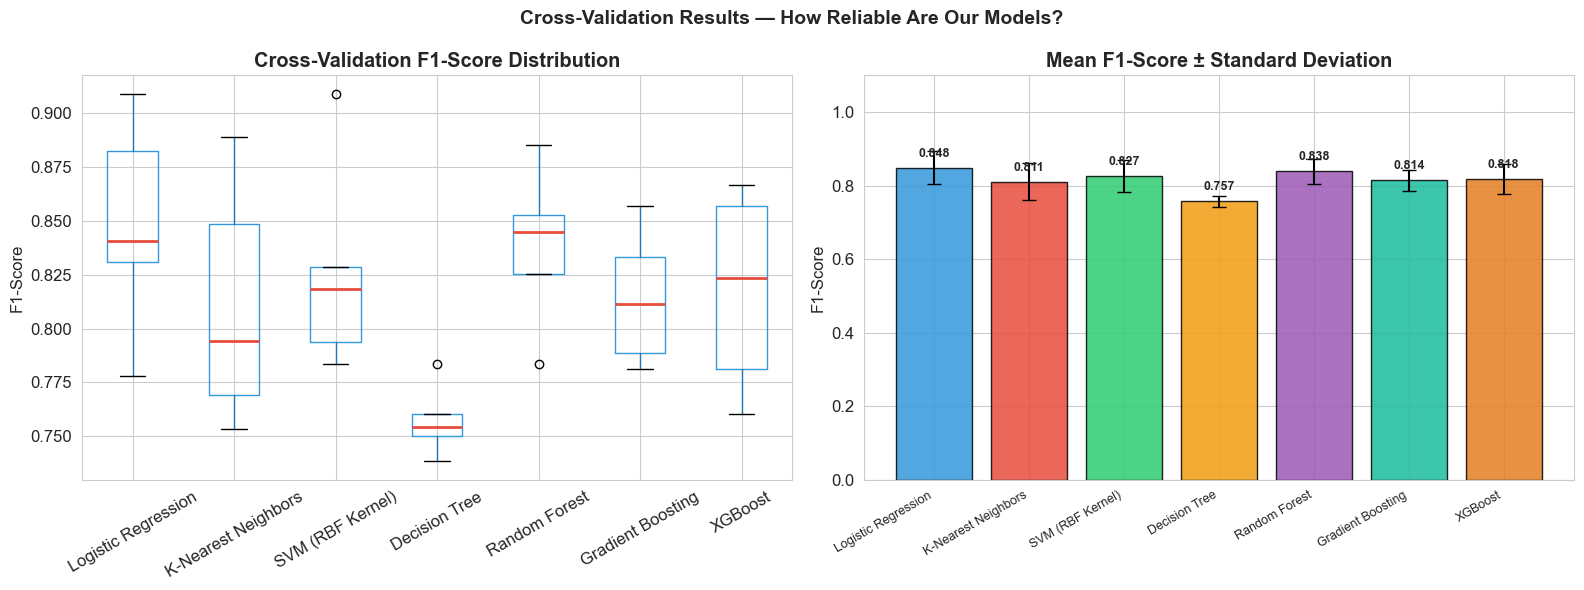


🏆 FINAL RANKING (by Cross-Validated F1-Score)
  🥇 1. Logistic Regression       → F1 = 0.8481 ± 0.0452
  🥈 2. Random Forest             → F1 = 0.8385 ± 0.0335
  🥉 3. SVM (RBF Kernel)          → F1 = 0.8267 ± 0.0443
     4. XGBoost                   → F1 = 0.8178 ± 0.0414
     5. Gradient Boosting         → F1 = 0.8144 ± 0.0281
     6. K-Nearest Neighbors       → F1 = 0.8109 ± 0.0506
     7. Decision Tree             → F1 = 0.7574 ± 0.0150

✅ RECOMMENDED MODEL: Logistic Regression
   (Most reliable performance across all 5 folds)


In [35]:
# CV Results Visualization
cv_df = pd.DataFrame({
    name: vals['scores'] for name, vals in cv_results.items()
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
cv_df.boxplot(ax=axes[0], rot=30, grid=True,
              boxprops=dict(color='#3498db'),
              medianprops=dict(color='#e74c3c', linewidth=2))
axes[0].set_title('Cross-Validation F1-Score Distribution', fontweight='bold')
axes[0].set_ylabel('F1-Score')

# Mean ± Std bar chart
means = [cv_results[name]['mean'] for name in models]
stds = [cv_results[name]['std'] for name in models]
x_pos = range(len(models))

bars = axes[1].bar(x_pos, means, yerr=stds, capsize=5,
                   color=colors_roc, edgecolor='black', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models.keys(), rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Mean F1-Score ± Standard Deviation', fontweight='bold')
axes[1].set_ylim(0, 1.1)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{mean:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Cross-Validation Results — How Reliable Are Our Models?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Final ranking
print("\n" + "=" * 60)
print("🏆 FINAL RANKING (by Cross-Validated F1-Score)")
print("=" * 60)
ranking = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
for rank, (name, vals) in enumerate(ranking, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    print(f"  {medal} {rank}. {name:25s} → F1 = {vals['mean']:.4f} ± {vals['std']:.4f}")

best_cv_model = ranking[0][0]
print(f"\n✅ RECOMMENDED MODEL: {best_cv_model}")
print(f"   (Most reliable performance across all 5 folds)")

### 9. Hyperparameter Tuning

 **Why tune?** So far we used reasonable default hyperparameters.
 But the "best" values depend on the specific dataset — tuning finds them.

 **GridSearchCV vs RandomizedSearchCV:**
 - **GridSearchCV**: Tries EVERY combination in the grid. Exhaustive → guaranteed best.
 - **RandomizedSearchCV**: Samples random combos. Faster but might miss the best.
 - **Our choice: GridSearchCV** — because the dataset is small (303 rows),
   training is fast, so we can afford exhaustive search.

 **Why tune inside CV (GridSearchCV) and not on the test set?**
 If we pick hyperparameters based on test set performance, we're "cheating" —
 the test set is no longer unseen. GridSearchCV tunes using ONLY the training
 data (via internal cross-validation), keeping the test set truly held out.

In [36]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grids for each model
# Each key uses 'classifier__param' because models are inside Pipelines

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        # C = inverse regularization strength
        # Small C → strong regularization (simpler model, less overfitting)
        # Large C → weak regularization (complex model, fits training data more)
        # WHY these values? Log-scale search covers a wide range efficiently
        'classifier__solver': ['lbfgs', 'liblinear'],
        # lbfgs → good default for small datasets
        # liblinear → works better with L1 regularization (feature selection)
    },

    'K-Nearest Neighbors': {
        'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
        # WHY odd numbers? Avoids ties in binary classification
        # WHY this range? k=3 (flexible) to k=15 (smooth). For ~300 samples,
        # k > 15 would over-smooth and lose local patterns
        'classifier__weights': ['uniform', 'distance'],
        # uniform → all neighbors vote equally
        # distance → closer neighbors have more influence (often better)
        'classifier__metric': ['euclidean', 'manhattan'],
        # euclidean → standard L2 distance
        # manhattan → L1 distance, more robust to outliers
    },

    'SVM (RBF Kernel)': {
        'classifier__C': [0.1, 1, 10, 100],
        # C controls the tradeoff between smooth boundary and classifying training points correctly
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        # gamma = how far the influence of a single training example reaches
        # 'scale' = 1/(n_features * X.var()) → adapts to data
        # 'auto' = 1/n_features → simpler
        # Small gamma → large influence radius → smoother boundary
        # Large gamma → small radius → more complex boundary (risk of overfitting)
    },

    'Decision Tree': {
        'classifier__max_depth': [3, 5, 7, 10, None],
        # None = unlimited depth (full tree) → likely overfits
        # WHY test None? To prove that limiting depth helps
        'classifier__min_samples_split': [2, 5, 10],
        # Minimum samples required to split a node
        # Higher → more conservative splits → less overfitting
        'classifier__min_samples_leaf': [1, 2, 4],
        # Minimum samples in a leaf. Higher → smoother predictions
        'classifier__criterion': ['gini', 'entropy'],
        # gini → faster, works well in practice
        # entropy → information gain, sometimes slightly better
    },

    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        # Number of trees. More = better but slower. 200 is plenty for 300 samples.
        'classifier__max_depth': [5, 10, 15, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2],
        # WHY fewer options than Decision Tree? Random Forest is already regularized
        # by averaging trees, so it's less sensitive to individual tree params
    },

    'Gradient Boosting': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        # learning_rate × n_estimators interact:
        # low LR + many trees = better generalization but slower
        # high LR + few trees = faster but may overshoot
        'classifier__max_depth': [2, 3, 5],
        # Boosting works best with shallow trees (weak learners)
        # WHY not deeper? Each tree corrects the previous one's errors.
        # Deep trees are too "opinionated" → boosting can't correct them well
        'classifier__subsample': [0.8, 1.0],
        # Fraction of samples used per tree. < 1.0 adds randomness → reduces overfitting
    },

    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth': [2, 3, 5],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0],
        # colsample_bytree = fraction of FEATURES used per tree
        # WHY XGBoost has this but sklearn GB doesn't? XGBoost was designed with
        # more regularization options. Using < 1.0 is like Random Forest's feature
        # bagging but applied to boosting → reduces overfitting
        'classifier__reg_alpha': [0, 0.1],
        # L1 regularization. Encourages sparsity (some feature weights → 0)
        # WHY only 0 and 0.1? We don't want too many combos. Light L1 is enough.
    },
}

# Print grid sizes
print("HYPERPARAMETER TUNING — Grid Sizes")
print("=" * 60)
total_fits = 0
for name, grid in param_grids.items():
    combos = 1
    for param, values in grid.items():
        combos *= len(values)
    fits = combos * 5  # 5-fold CV
    total_fits += fits
    print(f"  {name:25s} → {combos:4d} combinations × 5 folds = {fits:5d} fits")
print(f"\n  Total fits across all models: {total_fits}")
print(f"  (Dataset is small so this will run quickly)")

HYPERPARAMETER TUNING — Grid Sizes
  Logistic Regression       →   10 combinations × 5 folds =    50 fits
  K-Nearest Neighbors       →   24 combinations × 5 folds =   120 fits
  SVM (RBF Kernel)          →   20 combinations × 5 folds =   100 fits
  Decision Tree             →   90 combinations × 5 folds =   450 fits
  Random Forest             →   72 combinations × 5 folds =   360 fits
  Gradient Boosting         →   72 combinations × 5 folds =   360 fits
  XGBoost                   →  288 combinations × 5 folds =  1440 fits

  Total fits across all models: 2880
  (Dataset is small so this will run quickly)


In [37]:
# Run GridSearchCV for each model
# WHY GridSearchCV and not manual loops?
# GridSearchCV handles the CV splitting, fitting, scoring, and result tracking
# all in one clean call. It also uses the TRAINING set only for tuning.

print("\n" + "=" * 60)
print("TUNING ALL MODELS (GridSearchCV, 5-Fold Stratified)")
print("=" * 60)

best_params = {}
tuned_results = {}
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in models.items():
    print(f"\n🔧 Tuning {name}...")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=cv_tune,
        scoring='f1',           # Optimize for F1 (recall + precision balance)
        n_jobs=-1,              # Use all CPU cores for speed
        verbose=0,
        return_train_score=True  # Track training score to detect overfitting
    )

    grid_search.fit(X_train, y_train)

    # Store best params and score
    best_params[name] = grid_search.best_params_
    best_estimator = grid_search.best_estimator_

    # Evaluate tuned model on test set
    y_pred_tuned = best_estimator.predict(X_test)
    y_prob_tuned = best_estimator.predict_proba(X_test)[:, 1]

    tuned_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred_tuned),
        'precision': precision_score(y_test, y_pred_tuned),
        'recall': recall_score(y_test, y_pred_tuned),
        'f1': f1_score(y_test, y_pred_tuned),
        'roc_auc': roc_auc_score(y_test, y_prob_tuned),
        'best_cv_f1': grid_search.best_score_,
        'y_pred': y_pred_tuned,
        'y_prob': y_prob_tuned,
    }

    print(f"   Best CV F1: {grid_search.best_score_:.4f}")
    print(f"   Test F1:    {tuned_results[name]['f1']:.4f}")
    print(f"   Best params:")
    for param, value in grid_search.best_params_.items():
        short_param = param.replace('classifier__', '')
        print(f"      {short_param}: {value}")


TUNING ALL MODELS (GridSearchCV, 5-Fold Stratified)

🔧 Tuning Logistic Regression...
   Best CV F1: 0.8651
   Test F1:    0.8116
   Best params:
      C: 0.1
      solver: lbfgs

🔧 Tuning K-Nearest Neighbors...
   Best CV F1: 0.8488
   Test F1:    0.7826
   Best params:
      metric: manhattan
      n_neighbors: 5
      weights: uniform

🔧 Tuning SVM (RBF Kernel)...
   Best CV F1: 0.8565
   Test F1:    0.8219
   Best params:
      C: 10
      gamma: 0.01

🔧 Tuning Decision Tree...
   Best CV F1: 0.8065
   Test F1:    0.7042
   Best params:
      criterion: entropy
      max_depth: 5
      min_samples_leaf: 2
      min_samples_split: 2

🔧 Tuning Random Forest...
   Best CV F1: 0.8498
   Test F1:    0.7887
   Best params:
      max_depth: 5
      min_samples_leaf: 1
      min_samples_split: 2
      n_estimators: 200

🔧 Tuning Gradient Boosting...
   Best CV F1: 0.8566
   Test F1:    0.8000
   Best params:
      learning_rate: 0.05
      max_depth: 2
      n_estimators: 100
      subsamp

In [38]:
# --- 9.1 Compare Tuned vs Untuned ---
print("\n" + "=" * 60)
print("TUNED vs UNTUNED COMPARISON (Test Set F1-Score)")
print("=" * 60)

comparison_data = []
for name in models:
    untuned_f1 = results[name]['f1']
    tuned_f1 = tuned_results[name]['f1']
    diff = tuned_f1 - untuned_f1
    arrow = "↑" if diff > 0 else "↓" if diff < 0 else "="
    comparison_data.append({
        'Model': name,
        'Untuned F1': untuned_f1,
        'Tuned F1': tuned_f1,
        'Change': diff,
    })
    print(f"  {name:25s} │ {untuned_f1:.4f} → {tuned_f1:.4f}  ({arrow} {abs(diff):.4f})")

comparison_df = pd.DataFrame(comparison_data)


TUNED vs UNTUNED COMPARISON (Test Set F1-Score)
  Logistic Regression       │ 0.8286 → 0.8116  (↓ 0.0170)
  K-Nearest Neighbors       │ 0.7576 → 0.7826  (↑ 0.0250)
  SVM (RBF Kernel)          │ 0.8533 → 0.8219  (↓ 0.0314)
  Decision Tree             │ 0.7887 → 0.7042  (↓ 0.0845)
  Random Forest             │ 0.7887 → 0.7887  (= 0.0000)
  Gradient Boosting         │ 0.7941 → 0.8000  (↑ 0.0059)
  XGBoost                   │ 0.8000 → 0.7941  (↓ 0.0059)


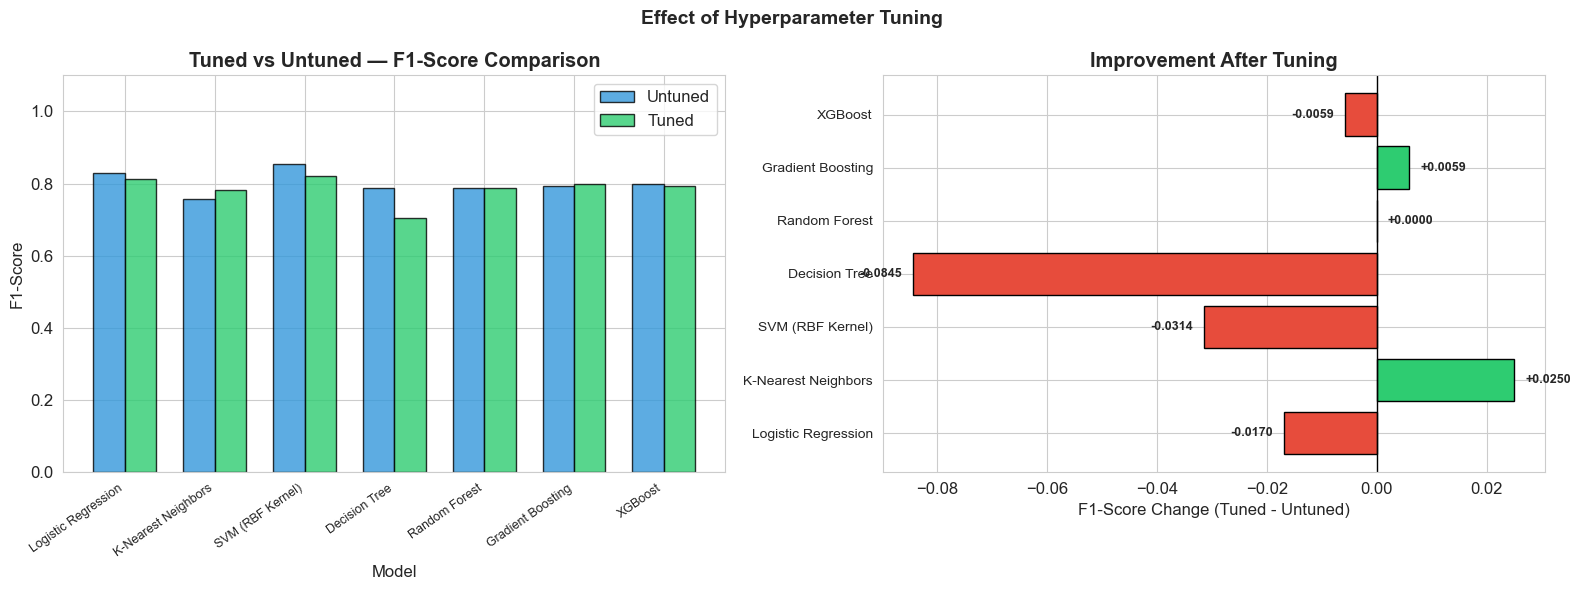

In [39]:
# --- 9.2 Visual Comparison: Tuned vs Untuned ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
x = np.arange(len(comparison_df))
width = 0.35

bars1 = axes[0].bar(x - width/2, comparison_df['Untuned F1'], width,
                    label='Untuned', color='#3498db', edgecolor='black', alpha=0.8)
bars2 = axes[0].bar(x + width/2, comparison_df['Tuned F1'], width,
                    label='Tuned', color='#2ecc71', edgecolor='black', alpha=0.8)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Tuned vs Untuned — F1-Score Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=35, ha='right', fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Improvement chart
colors_change = ['#2ecc71' if c >= 0 else '#e74c3c' for c in comparison_df['Change']]
axes[1].barh(range(len(comparison_df)), comparison_df['Change'],
             color=colors_change, edgecolor='black')
axes[1].set_yticks(range(len(comparison_df)))
axes[1].set_yticklabels(comparison_df['Model'], fontsize=10)
axes[1].set_xlabel('F1-Score Change (Tuned - Untuned)')
axes[1].set_title('Improvement After Tuning', fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=1)
for i, v in enumerate(comparison_df['Change']):
    axes[1].text(v + 0.002 if v >= 0 else v - 0.002, i,
                f'{v:+.4f}', va='center', fontweight='bold',
                ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('Effect of Hyperparameter Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# --- 9.3 Tuned Models — Full Metrics Table ---
tuned_metrics_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['y_pred', 'y_prob', 'best_cv_f1']}
    for name, metrics in tuned_results.items()
}).T.round(4)

tuned_metrics_df = tuned_metrics_df.sort_values('f1', ascending=False)

print("\nTUNED MODEL COMPARISON (sorted by F1-Score)")
print("=" * 75)
print(tuned_metrics_df.to_string())


TUNED MODEL COMPARISON (sorted by F1-Score)
                     accuracy  precision  recall      f1  roc_auc
SVM (RBF Kernel)       0.7869     0.7500  0.9091  0.8219   0.8961
Logistic Regression    0.7869     0.7778  0.8485  0.8116   0.8874
Gradient Boosting      0.7705     0.7568  0.8485  0.8000   0.8755
XGBoost                0.7705     0.7714  0.8182  0.7941   0.8831
Random Forest          0.7541     0.7368  0.8485  0.7887   0.9037
K-Nearest Neighbors    0.7541     0.7500  0.8182  0.7826   0.8842
Decision Tree          0.6557     0.6579  0.7576  0.7042   0.6834


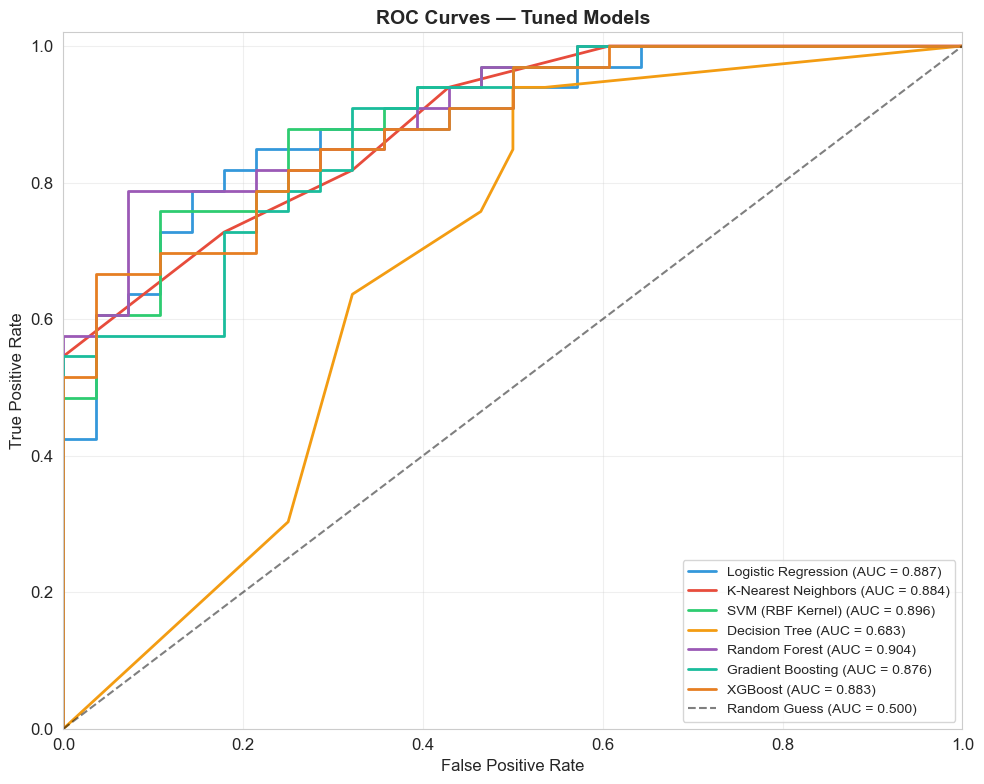

In [41]:
# --- 9.4 ROC Curves — Tuned Models ---
fig, ax = plt.subplots(figsize=(10, 8))

colors_roc_tuned = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for (name, metrics), color in zip(tuned_results.items(), colors_roc_tuned):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    auc = metrics['roc_auc']
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Tuned Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# --- 9.5 Best Tuned Model — Final Report ---
best_tuned_name = tuned_metrics_df.index[0]
print(f"\n🏆 BEST TUNED MODEL: {best_tuned_name}")
print("=" * 60)
print(classification_report(y_test, tuned_results[best_tuned_name]['y_pred'],
                            target_names=['No Disease', 'Heart Disease']))

print("\nBest Hyperparameters:")
for param, value in best_params[best_tuned_name].items():
    short_param = param.replace('classifier__', '')
    print(f"  {short_param}: {value}")


🏆 BEST TUNED MODEL: SVM (RBF Kernel)
               precision    recall  f1-score   support

   No Disease       0.86      0.64      0.73        28
Heart Disease       0.75      0.91      0.82        33

     accuracy                           0.79        61
    macro avg       0.80      0.78      0.78        61
 weighted avg       0.80      0.79      0.78        61


Best Hyperparameters:
  C: 10
  gamma: 0.01


In [43]:
# --- 9.6 All Best Hyperparameters (Reference) ---
print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS FOR EACH MODEL")
print("=" * 60)
for name, params in best_params.items():
    print(f"\n📌 {name}:")
    for param, value in params.items():
        short_param = param.replace('classifier__', '')
        print(f"    {short_param}: {value}")


BEST HYPERPARAMETERS FOR EACH MODEL

📌 Logistic Regression:
    C: 0.1
    solver: lbfgs

📌 K-Nearest Neighbors:
    metric: manhattan
    n_neighbors: 5
    weights: uniform

📌 SVM (RBF Kernel):
    C: 10
    gamma: 0.01

📌 Decision Tree:
    criterion: entropy
    max_depth: 5
    min_samples_leaf: 2
    min_samples_split: 2

📌 Random Forest:
    max_depth: 5
    min_samples_leaf: 1
    min_samples_split: 2
    n_estimators: 200

📌 Gradient Boosting:
    learning_rate: 0.05
    max_depth: 2
    n_estimators: 100
    subsample: 0.8

📌 XGBoost:
    colsample_bytree: 0.8
    learning_rate: 0.05
    max_depth: 2
    n_estimators: 100
    reg_alpha: 0.1
    subsample: 0.8


### Summary

#### What we did:
 1. Loaded and explored the UCI Heart Disease dataset (303 patients, 14 features)
 2. Performed comprehensive EDA (distributions, correlations, outliers)
 3. Preprocessed data with proper handling:
    - StandardScaler for numerical features (handles outliers better than MinMaxScaler)
    - One-Hot Encoding for nominal categoricals (no false ordinal relationships)
    - Passthrough for binary and ordinal features
 4. Trained 7 classical ML models with justified hyperparameters
 5. Evaluated using accuracy, precision, recall, F1-score, ROC-AUC
 6. Analyzed feature importance (which health factors matter most)
 7. Validated with 5-Fold Stratified Cross-Validation for reliable estimates
 8. Tuned all models with GridSearchCV and compared tuned vs untuned performance

#### Key Takeaway:
 For medical prediction, RECALL is king — missing a sick patient is far worse
 than a false alarm. Always evaluate beyond just accuracy!

